# Практическое задание «Поиск выбросов»

## Шаблон для выполнения

### Часть 1. Выявление и визуализация выбросов

В этом задании вы будете работать с реальным датасетом, в котором содержится информация о более чем 50 000 бриллиантах. У каждого бриллианта есть несколько характеристик:

• **carat**: вес бриллианта. Более крупные бриллианты, как правило, дороже.

• **cut**: качество огранки. Измеряется по градации качества: "Fair", "Good", "Very Good",
"Premium", "Ideal".

• **color**: оценка цвета бриллианта. Ранжируется от "J" (худшая) to "D" (лучшая).

• **clarity**: чистота бриллианта. Описывается кодом (по возрастанию качества): "I1" (худшая), "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF" (лучшая).

• **price**: цена бриллианта в долларах США.

Измерения:

• **x, y, z**, длина, ширина и глубина в мм

• Глубина и площадка - это отношения (в %)

• **depth** = 2 z / (x+y)

• **table** = ширина верха / наибольшая ширина

![image.png](https://u.netology.ru/backend/uploads/lms/content_assets/file/14718/tg_image_378460715.png)

In [12]:
import seaborn as sns
diamonds = sns.load_dataset("diamonds", cache=True, data_home=None)
diamonds.head(5)

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


1.1. Загрузите файл `diamonds.csv` из библиотеки seaborn. Проведите предварительный анализ:

 - Получите базовые статистики датафрейма.
 - Найдите топ-3 столбца с наибольшим количеством пропусков.
 - Посмотрите уникальные значения в столбцах `carat`, `depth`, `table` и `price`. Есть ли там странные значения?
 - Для каждой из четырх переменных постройте гистограмму и ящик с усами (boxplot).

*Объясните природу выбросов: являются ли они естественными или синтетическими?*

In [13]:
import seaborn as sns
diamonds = sns.load_dataset("diamonds")


display(diamonds.describe())
ln = len(diamonds)

# Проанализируйте пропуски в данных
temp = diamonds.count().reset_index()
temp.columns = ['column', 'count']
temp['ptc_lost'] = (1 - temp['count'] / ln) * 100
temp['dtype'] = diamonds.dtypes.values
temp = temp[['column', 'count', 'ptc_lost', 'dtype']]
display(temp)

df_work = diamonds[['carat','depth','table','price']].copy()
df_work.nunique()


,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


,column,count,ptc_lost,dtype
0,carat,53940,0.0,float64
1,cut,53940,0.0,category
2,color,53940,0.0,category
3,clarity,53940,0.0,category
4,depth,53940,0.0,float64
5,table,53940,0.0,float64
6,price,53940,0.0,int64
7,x,53940,0.0,float64
8,y,53940,0.0,float64
9,z,53940,0.0,float64


carat      273
depth      184
table      127
price    11602
dtype: int64

**Комментарий**

Не возможно выделить топ 3 столбца с пропусками, потому что пропусков в данных нет

Странных значений не обнаружил.

Есть выбросы, выгледят ествественно (дорогие/крупные бриллианты)

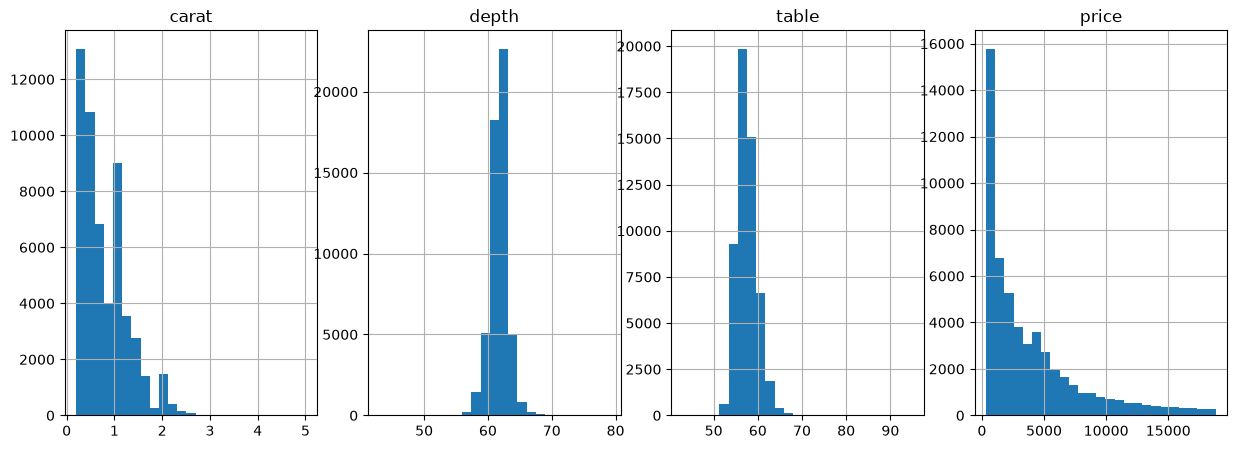

C:\Users\wolftik\AppData\Local\Temp\ipykernel_11612\2511750222.py:17: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0][0].boxplot(df_work['carat'], vert=False)
C:\Users\wolftik\AppData\Local\Temp\ipykernel_11612\2511750222.py:18: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0][1].boxplot(df_work['depth'], vert=False)
C:\Users\wolftik\AppData\Local\Temp\ipykernel_11612\2511750222.py:19: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1][0].boxplot(df_work['table'], vert=False)
C:\Users\wolftik\AppData\Local\Temp\ipykernel_11612\2511750222.py:20: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed i

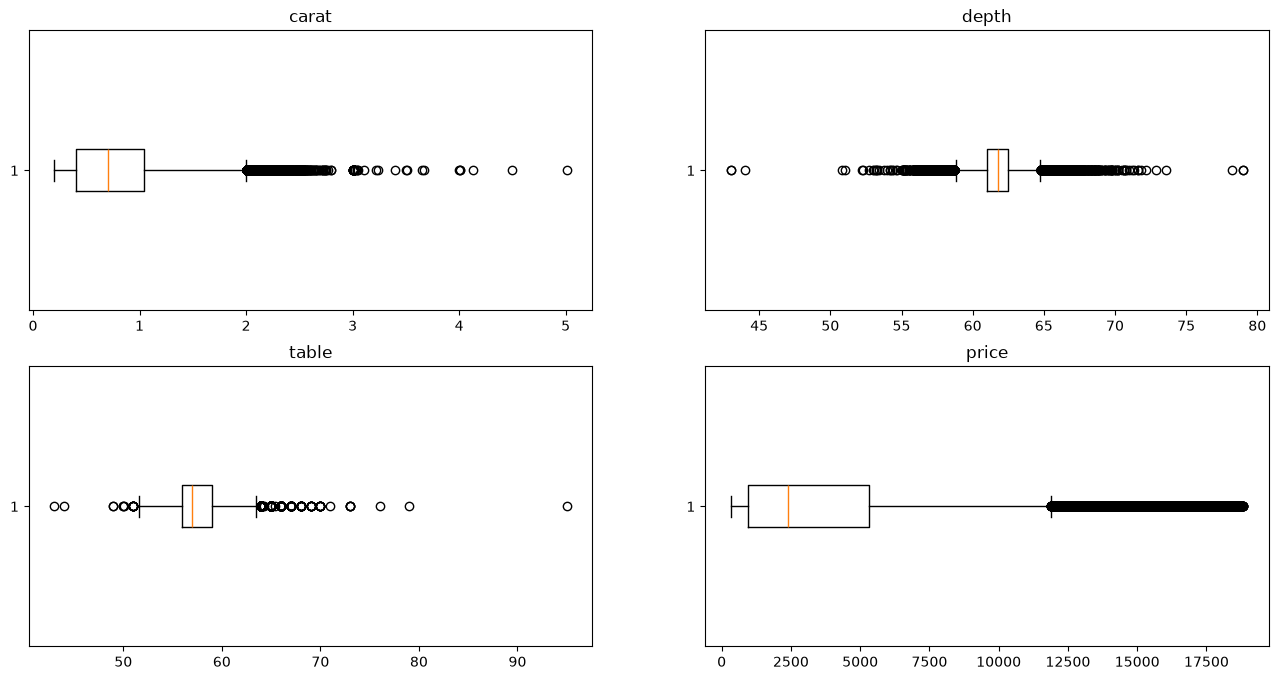

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4)
df_work['carat'].hist(bins=25, figsize=(15,5), ax=axes[0])
df_work['depth'].hist(bins=25, figsize=(15,5), ax=axes[1])
df_work['table'].hist(bins=25, figsize=(15,5), ax=axes[2])
df_work['price'].hist(bins=25, figsize=(15,5), ax=axes[3])
axes[0].set_title('carat')
axes[1].set_title('depth')
axes[2].set_title('table')
axes[3].set_title('price')
plt.show()



fig, axes = plt.subplots(2, 2, figsize=(16, 8))
axes[0][0].boxplot(df_work['carat'], vert=False)
axes[0][1].boxplot(df_work['depth'], vert=False)
axes[1][0].boxplot(df_work['table'], vert=False)
axes[1][1].boxplot(df_work['price'], vert=False)
axes[0][0].set_title('carat')
axes[0][1].set_title('depth')
axes[1][0].set_title('table')
axes[1][1].set_title('price')
plt.show()

1.2. Обучите регрессионную модель предсказания цены бриллианта в зависимости от значений веса (в каратах), площадки и глубины.

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics

X_hist = df_work[['carat','table','depth']]
y_target = df_work['price']

# Обучите линейную модель
regressor = LinearRegression()                    
regressor.fit(X_hist, y_target)       


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[7858.77,-104.47,-151.24]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['carat','table','depth']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.3e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


### Шаг 2. Обработка признаков

2.1. Реализуйте модельный метод для анализа выбросов.
- Постройте линейную модель для описания данных
- Визуализируйте предсказания

*Определите выбросы по графику предсказаний. Где модель ошибается сильнее всего?*

In [16]:
import numpy as np


# Получите предсказания
y_pred = regressor.predict(X_hist)

# Получите остатки
residuals = y_target - y_pred 

# Установите пороговое значение
# Общепринятое пороговое значение - три стандартных отклонения
threshold = 3 * np.std(residuals)

# Определите выбросы
# (воспользуйтесь методом np.abs для получения значения по модулю)
outliers = np.abs(residuals) > threshold
l_reg_outliers_prc = outliers.sum()/len(residuals)*100

Визуализируйте предсказанную линию на графике и определите выбросы.

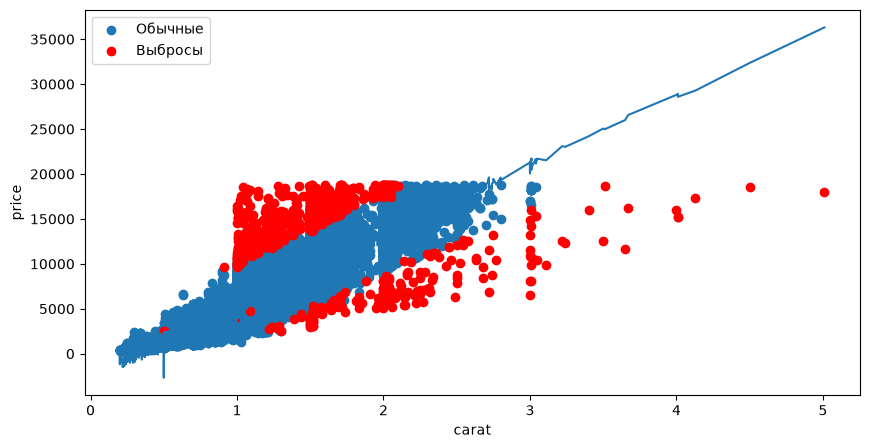

In [17]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10,5))


# Обычные точки
plt.scatter(X_hist.loc[~outliers, 'carat'], y_target[~outliers], label='Обычные')

# Выбросы
plt.scatter(X_hist.loc[outliers, 'carat'], y_target[outliers], color='red', label='Выбросы')

# Линия регрессии
order = np.argsort(X_hist['carat'])
plt.plot(X_hist['carat'].iloc[order], y_pred[order])

plt.xlabel('carat')
plt.ylabel('price')
plt.legend()
plt.show()

2.2. Реализуйте метод опорных векторов (SVM) для поиска выбросов.

In [18]:
from sklearn.svm import OneClassSVM

# # Маштабируем даныне так как сильная разница между максимальным и минимаьным значением наших атрибутов
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X_hist)


svm = OneClassSVM(nu=0.1)
svm.fit(X_hist)
predict_x_svm = svm.predict(X_hist)
outliers_svm = predict_x_svm == -1
outliers_svm_prc = outliers_svm.sum()/len(predict_x_svm)*100
outliers_svm_prc

np.float64(10.0)

2.3. Реализуйте алгоритм Isolation Forest

In [19]:
from sklearn.ensemble import IsolationForest

forest = IsolationForest()
forest.fit(X_hist)
predict_x_forest = forest.predict(X_hist)
outliers_forest = predict_x_forest == -1
outliers_forest_prc = outliers_forest.sum()/len(predict_x_forest)*100
outliers_forest_prc

np.float64(16.866889136077123)

2.4. Сравните работу методов: какой из них предпочтительнее для вашей задачи?

In [20]:
{'l_reg_outliers_prc':l_reg_outliers_prc,
'outliers_svm_prc':outliers_svm_prc,
'outliers_forest_prc':outliers_forest_prc}

{'l_reg_outliers_prc': np.float64(2.274749721913237),
 'outliers_svm_prc': np.float64(10.0),
 'outliers_forest_prc': np.float64(16.866889136077123)}

2.5. Удалите выбросы выбранным методом

In [ ]:
# Выбираем Isolation Forest как предпочтительный метод (быстро работает на больших данных и устойчив к выбросам).
# Удаляем выбросы
df_clean = df_work[~outliers_forest].copy()

print("Строк было:", len(df_work))
print("Удалено выбросов:", int(outliers_forest.sum()))
print("Строк стало:", len(df_clean))

Строк было: 53940
Удалено выбросов: 9098
Строк стало: 44842


### Часть 3. Обучение

Снова обучите регрессионную модель предсказания цены бриллианта в зависимости от значений веса (в каратах), площадки и глубины - после улучшения признаков. Как поменялось качество предсказания после удаления выбросов?

In [22]:
# Признаки и цель на очищенных данных
X_clean = df_clean[["carat","table","depth"]]
y_clean = df_clean["price"]

# Обучаем новую линейную модель на очищенных данных
regressor_clean = LinearRegression()
regressor_clean.fit(X_clean, y_clean)

# Предсказания на очищенных данных
y_pred_clean = regressor_clean.predict(X_clean)

# Сравнение качества до и после очистки (RMSE = корень из MSE)
rmse_before = np.sqrt(metrics.mean_squared_error(y_target, y_pred))
rmse_after = np.sqrt(metrics.mean_squared_error(y_clean, y_pred_clean))

print("R^2 ДО очистки:   ", round(regressor.score(X_hist, y_target), 4))
print("R^2 ПОСЛЕ очистки:", round(regressor_clean.score(X_clean, y_clean), 4))

print("RMSE ДО очистки:   ", round(rmse_before, 2))
print("RMSE ПОСЛЕ очистки:", round(rmse_after, 2))

R^2 ДО очистки:    0.8537
R^2 ПОСЛЕ очистки: 0.8168
RMSE ДО очистки:    1526.04
RMSE ПОСЛЕ очистки: 1327.88


### Итоги (рефлексия)

Напишите выводы (5–7 предложений):

1. Какой метод поиска выбросов вы сочли наиболее предпочтительным?
2. Как сильно выросла точность модели после очистки?

**Выводы:**

### Какой метод предпочтительнее
- Из трёх методов (модельный, OneClassSVM, Isolation Forest) для этой задачи я выбрал Isolation Forest.
- Он быстро работает на большом датасете (~54 тыс. строк), не требует масштабирования признаков и устойчив к выбросам.
- OneClassSVM на таких объёмах работает заметно медленнее, а модельный метод по остаткам нашёл лишь ~2,3% выбросов.

### Как изменилась точность после очистки
- После удаления выбросов RMSE снизился с 1526 до 1328 долларов, то есть модель стала точнее предсказывать цену.
- R^2 при этом снизился с 0.8537 до 0.8168, так как сравнение проводится на разных выборках: после очистки убраны дорогие бриллианты и уменьшилась дисперсия цены, от которой отсчитывается R^2.
- В абсолютных деньгах ошибка модели уменьшилась, что говорит о положительном эффекте очистки данных от выбросов.